**PSMDSSC 103 - Applied Machine Learning**

Assignment 3

Levi P. Caaya III
MEng CpE 1st Year 2nd Sem AY 2025-2026

# Logistic Regression

## Import Necessary Libraries

In [212]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


## Load Dataset

In [213]:
filepath = "https://raw.githubusercontent.com/levi3612/ML_datasets/refs/heads/main/insurance_data.csv"
df = pd.read_csv(filepath)
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


## Do the EDA

In [214]:
df.describe()

,age,bought_insurance
count,27.000000,27.000000
mean,39.666667,0.518519
std,15.745573,0.509175
min,18.000000,0.000000
25%,25.000000,0.000000
50%,45.000000,1.000000
75%,54.500000,1.000000
max,62.000000,1.000000


In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               27 non-null     int64
 1   bought_insurance  27 non-null     int64
dtypes: int64(2)
memory usage: 564.0 bytes


In [216]:
df.shape

(27, 2)

In [217]:
df.columns

Index(['age', 'bought_insurance'], dtype='object')

### Visualize the data

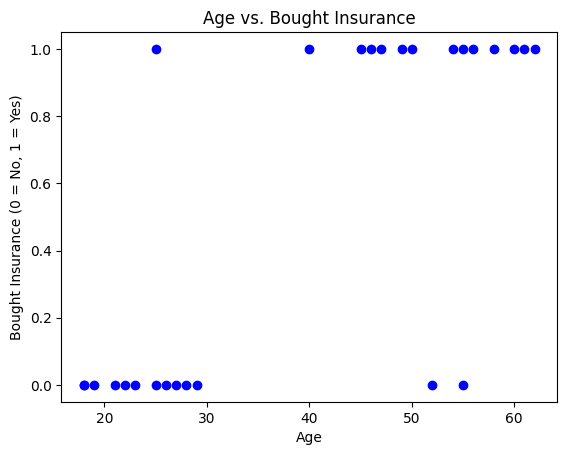

In [218]:
plt.scatter(df.age, df.bought_insurance, color = 'blue')
plt.xlabel('Age')
plt.ylabel('Bought Insurance (0 = No, 1 = Yes)')
plt.title('Age vs. Bought Insurance')
plt.show()

In [219]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## Assign X and y

In [220]:
y = df['bought_insurance']
X = df['age'].values.reshape(-1, 1)

## Split the data set 80 - 20

In [221]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25)

# Model #1 Simple Logistic Regression

### Create model

In [222]:
myLogR = LogisticRegression()
myLogR.fit(X_train, y_train)

LogisticRegression()

### Predict Using the Model

In [223]:
y_pred = myLogR.predict(X_test)

## Model Metrics

In [224]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, recall_score, precision_score, f1_score

In [225]:
#accuracy
accuracy_score(y_test, y_pred)

0.8571428571428571

In [226]:
#precision
precision_score(y_test, y_pred)

1.0

In [227]:
#recall
recall_score(y_test, y_pred)

0.8

In [228]:
#f1 score
f1_score(y_test, y_pred)

0.8888888888888888

<Figure size 800x600 with 0 Axes>

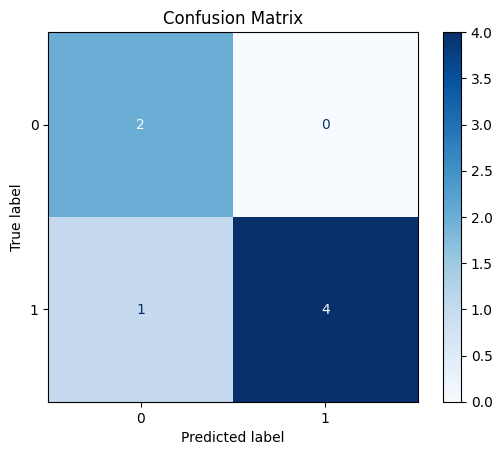

In [229]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels = ['0', '1'])

plt.figure(figsize = (8, 6))
disp.plot(cmap = plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


# Model #2 L2 Penalty + Cross Validation

In [230]:
from sklearn.linear_model import LogisticRegressionCV

In [231]:
myLogR2 = LogisticRegressionCV(
    penalty = 'l2',
    solver = 'lbfgs',
    cv = 5,
    scoring = 'recall',
)

myLogR2.fit(X_train, y_train)
y_pred2 = myLogR2.predict(X_test)

# Model #3 L1 Penalty + Cross Validation

In [232]:
myLogR3 = LogisticRegressionCV(
    penalty = 'l1',
    solver = 'liblinear',
    cv = 5,
    scoring = 'recall',
)

myLogR3.fit(X_train, y_train)
y_pred3 = myLogR3.predict(X_test)

# Evaluating Performance of the 3 Models

In [233]:
models = {
    'Simple Logistic Regression': y_pred,
    'L2 Penalty + Cross Validation': y_pred2,
    'L1 Penalty + Cross Validation': y_pred3
}

for name, preds in models.items():
  print(f'\n{name}')
  print('Accuracy:', accuracy_score(y_test, preds))
  print('Precison', precision_score(y_test, preds))
  print('Recall', recall_score(y_test, preds))
  print('f1:', f1_score(y_test, preds))


Simple Logistic Regression
Accuracy: 0.8571428571428571
Precison 1.0
Recall 0.8
f1: 0.8888888888888888

L2 Penalty + Cross Validation
Accuracy: 0.8571428571428571
Precison 1.0
Recall 0.8
f1: 0.8888888888888888

L1 Penalty + Cross Validation
Accuracy: 0.7142857142857143
Precison 0.7142857142857143
Recall 1.0
f1: 0.8333333333333334


## Confusion matrices

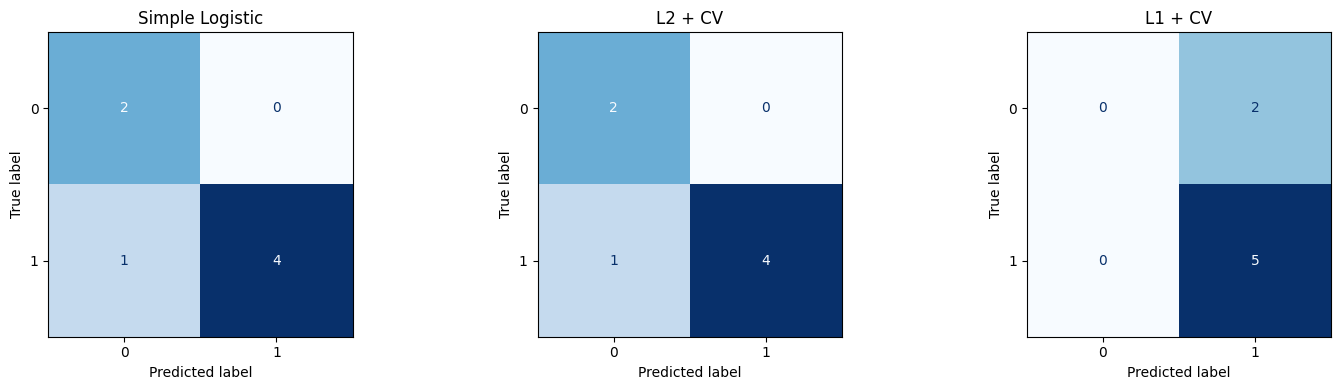

In [234]:
models = {
    "Simple Logistic": y_pred,
    "L2 + CV": y_pred2,
    "L1 + CV": y_pred3
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Interpreting Results

  
*   Three models have been created using simple logistic regression and cross validation with L2 and L1 penalties.
*   The results show that Simple Logistic Regression and Logistic Regression with Cross Validation and L2 penalty performed well with 0.857 accuracy.
*   **Training and testing data split was manipulated because 80 - 20 partition leads to 100% accuracy of all models**
*    Since the sourced dataset contains **single feature**, L2 and L1 penalties did not made very meaningful difference.


  
The results are as follows:

Simple Logistic Regression
Accuracy: 0.8571428571428571
Precison 1.0
Recall 0.8
f1: 0.8888888888888888

L2 Penalty + Cross Validation
Accuracy: 0.8571428571428571
Precison 1.0
Recall 0.8
f1: 0.8888888888888888

L1 Penalty + Cross Validation
Accuracy: 0.7142857142857143
Precison 0.7142857142857143
Recall 1.0
f1: 0.8333333333333334


# Link for Colab

https://colab.research.google.com/drive/1_ENIL4nqxWSTD-X5EeqXou12A_0N5hwv?usp=sharing